In [27]:
import dask
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from importlib.metadata import version

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries loaded successfully")
print("Dask version:", version("dask"))

All libraries loaded successfully
Dask version: 2025.11.0


In [28]:
import os
os.makedirs("../data", exist_ok=True)

# Verify files exist
import os
files = os.listdir("../data")
print("Files in ipl_data/:", files)

Files in ipl_data/: ['deliveries.csv', 'matches.csv']


In [29]:
t0 = time.time()

deliveries_dask = dd.read_csv(
    "../data//deliveries.csv",
    dtype={
        'dismissal_kind': 'object',
        'fielder': 'object',
        'player_dismissed': 'object'
    }
)

matches_dask = dd.read_csv(
    "../data//matches.csv",
    dtype={
        'method': 'object',
        'result_margin': 'float64',
        'target_overs': 'float64',
        'target_runs': 'float64'
    }
)

t_dask = time.time() - t0


t0 = time.time()

deliveries_pd = pd.read_csv("../data//deliveries.csv")
matches_pd    = pd.read_csv("../data//matches.csv")

t_pandas = time.time() - t0


print("=" * 50)
print("SCALABILITY COMPARISON")
print("=" * 50)
print(f"Dask   load time : {t_dask:.4f}s   ← lazy (no data read yet)")
print(f"Pandas load time : {t_pandas:.4f}s  ← eager (all data in RAM)")
print()

print(f"Deliveries shape : {deliveries_pd.shape}")
print(f"Matches shape    : {matches_pd.shape}")
print()

print(f"Dask partitions  : {deliveries_dask.npartitions}")
print(f"Estimated memory : {deliveries_pd.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print()

print("Dask task graph (lazy):")
print(deliveries_dask)

SCALABILITY COMPARISON
Dask   load time : 0.0488s   ← lazy (no data read yet)
Pandas load time : 1.1410s  ← eager (all data in RAM)

Deliveries shape : (260920, 17)
Matches shape    : (1095, 20)

Dask partitions  : 1
Estimated memory : 132.05 MB

Dask task graph (lazy):
Dask DataFrame Structure:
              match_id inning batting_team bowling_team   over   ball  batter  bowler non_striker batsman_runs extra_runs total_runs extras_type is_wicket player_dismissed dismissal_kind fielder
npartitions=1                                                                                                                                                                                     
                 int64  int64       string       string  int64  int64  string  string      string        int64      int64      int64      string     int64           string         string  string
                   ...    ...          ...          ...    ...    ...     ...     ...         ...          ...        

In [30]:
print("=== DELIVERIES COLUMNS ===")
print(deliveries_pd.columns.tolist())
print()
print("=== MATCHES COLUMNS ===")
print(matches_pd.columns.tolist())
print()
print("=== DELIVERIES SAMPLE ===")
display(deliveries_pd.head())
print()
print("=== MATCHES SAMPLE ===")
display(matches_pd.head())
print()

# Null check
print("=== NULL VALUES — DELIVERIES ===")
print(deliveries_pd.isnull().sum()[deliveries_pd.isnull().sum() > 0])

print("\n=== NULL VALUES — MATCHES ===")
print(matches_pd.isnull().sum()[matches_pd.isnull().sum() > 0])


=== DELIVERIES COLUMNS ===
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']

=== MATCHES COLUMNS ===
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

=== DELIVERIES SAMPLE ===


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN



=== MATCHES SAMPLE ===


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan



=== NULL VALUES — DELIVERIES ===
extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

=== NULL VALUES — MATCHES ===
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64


In [31]:
deliveries_dask = deliveries_dask.fillna({
    'player_dismissed': 'not_out',
    'dismissal_kind'  : 'not_out',
    'fielder'         : 'none'
})

matches_dask = matches_dask.fillna({
    'city'            : 'Unknown',
    'winner'          : 'No Result',
    'player_of_match' : 'N/A',
    'umpire1'         : 'Unknown',
    'umpire2'         : 'Unknown'
})

# ✅ Better: compute both together
t0 = time.time()
deliveries_clean, matches_clean = dd.compute(deliveries_dask, matches_dask)
t_compute = time.time() - t0

print(f"✅ Dask compute() finished in {t_compute:.3f}s")
print(f"   Deliveries: {deliveries_clean.shape[0]:,} rows")
print(f"   Matches   : {matches_clean.shape[0]:,} rows")

✅ Dask compute() finished in 2.221s
   Deliveries: 260,920 rows
   Matches   : 1,095 rows


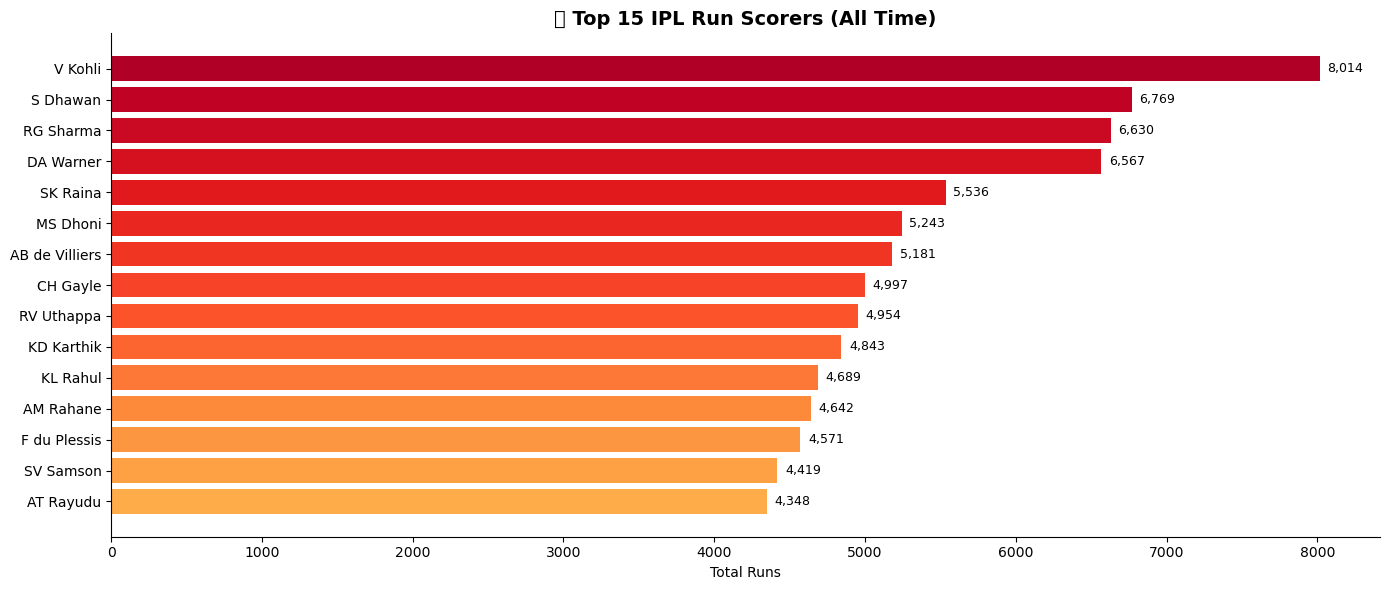


Top 5 Run Scorers:
     Batsman  Total_Runs
0    V Kohli        8014
1   S Dhawan        6769
2  RG Sharma        6630
3  DA Warner        6567
4   SK Raina        5536


In [32]:
batsman_runs_dask = (
    deliveries_dask
    .groupby('batter')['batsman_runs']
    .sum()
    .compute()         
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
batsman_runs_dask.columns = ['Batsman', 'Total_Runs']

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, 15))[::-1]
bars = ax.barh(batsman_runs_dask['Batsman'], batsman_runs_dask['Total_Runs'], color=colors)

for bar, val in zip(bars, batsman_runs_dask['Total_Runs']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Total Runs')
ax.set_title('🏏 Top 15 IPL Run Scorers (All Time)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('insight1_top_scorers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 Run Scorers:")
print(batsman_runs_dask.head())

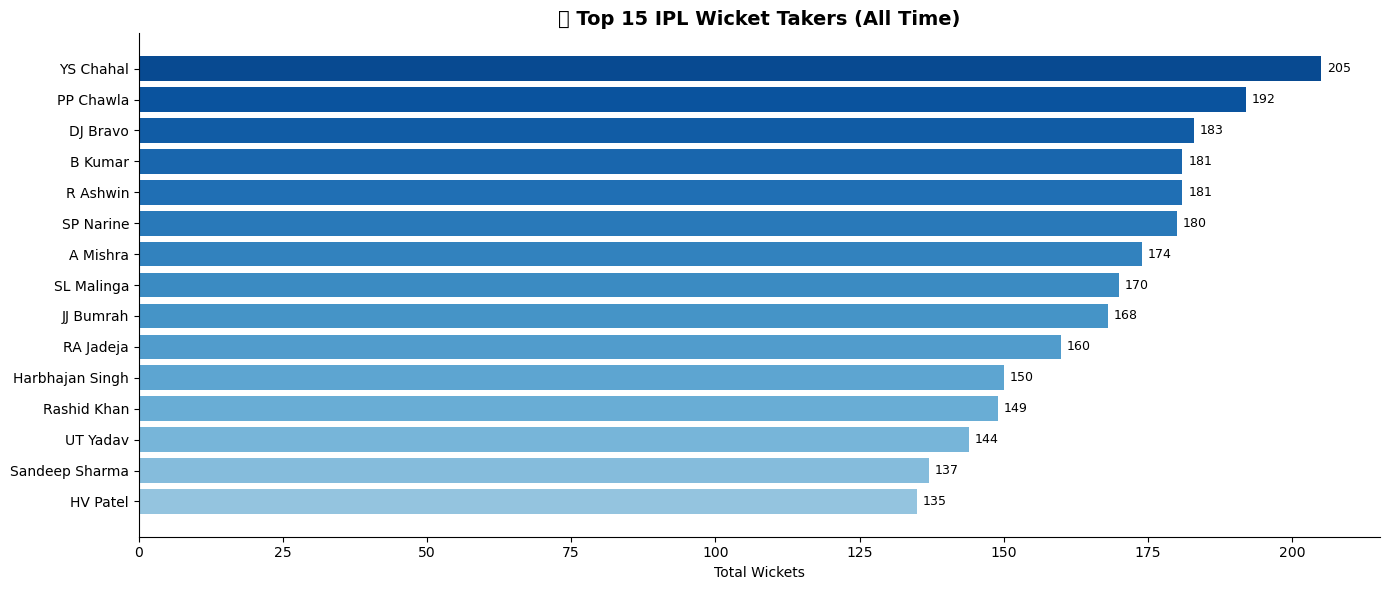


Top 5 Wicket Takers:
      Bowler  Wickets
0  YS Chahal      205
1  PP Chawla      192
2   DJ Bravo      183
3    B Kumar      181
4   R Ashwin      181


In [33]:
wickets_dask = deliveries_dask[
    (deliveries_dask['dismissal_kind'] != 'not_out') &
    (deliveries_dask['dismissal_kind'] != 'run out')
]

top_bowlers = (
    wickets_dask
    .groupby('bowler')['player_dismissed']
    .count()
    .compute()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_bowlers.columns = ['Bowler', 'Wickets']

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 15))[::-1]
bars = ax.barh(top_bowlers['Bowler'], top_bowlers['Wickets'], color=colors)

for bar, val in zip(bars, top_bowlers['Wickets']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Total Wickets')
ax.set_title('🎯 Top 15 IPL Wicket Takers (All Time)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('insight2_top_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 Wicket Takers:")
print(top_bowlers.head())

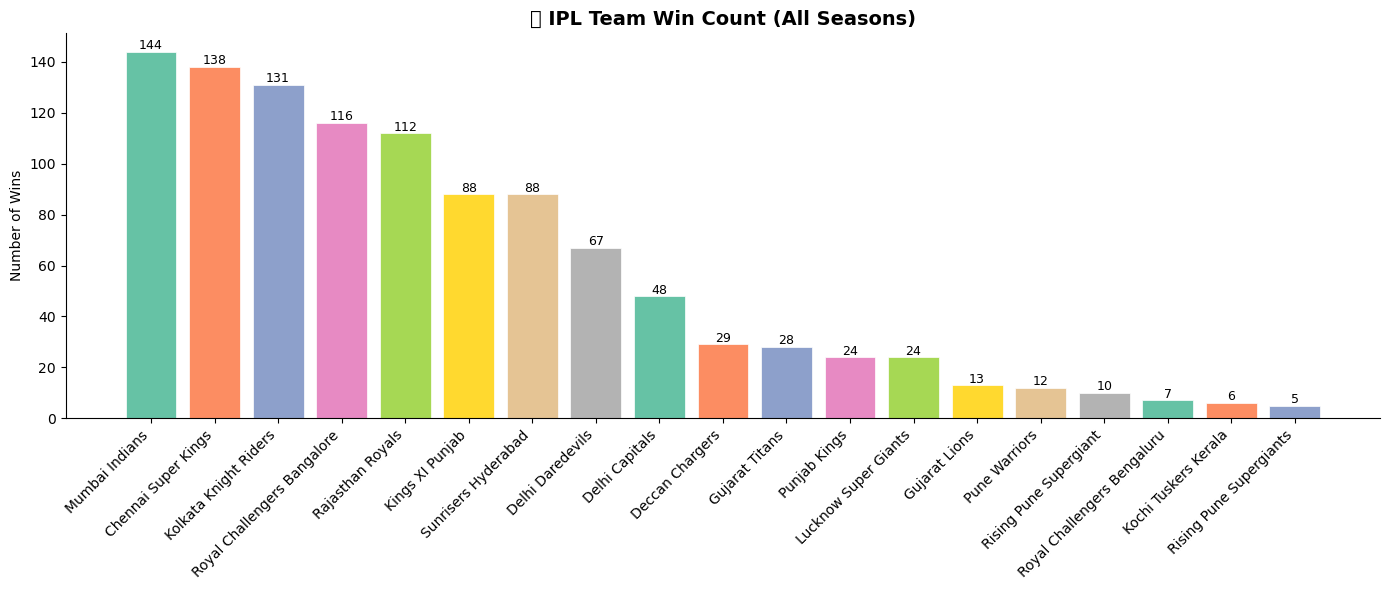

In [34]:
team_wins = (
    matches_dask[matches_dask['winner'] != 'No Result']
    .groupby('winner')['id']
    .count()
    .compute()
    .sort_values(ascending=False)
    .reset_index()
)
team_wins.columns = ['Team', 'Wins']

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette("Set2", len(team_wins))
bars = ax.bar(team_wins['Team'], team_wins['Wins'], color=palette, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, team_wins['Wins']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=9)

ax.set_ylabel('Number of Wins')
ax.set_title('🏆 IPL Team Win Count (All Seasons)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('insight3_team_wins.png', dpi=150, bbox_inches='tight')
plt.show()

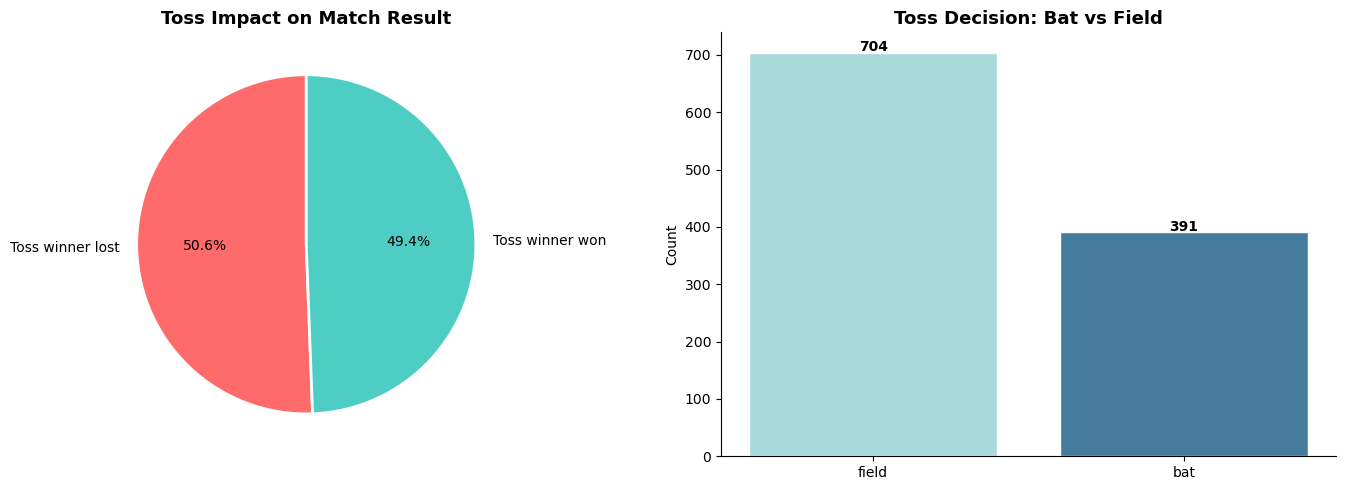


Toss → Match Win Rate: 50.6%


In [35]:
matches_df = matches_dask.compute()


matches_df['toss_win_match_win'] = matches_df['toss_winner'] == matches_df['winner']

toss_effect = matches_df['toss_win_match_win'].value_counts()
labels = ['Toss winner lost', 'Toss winner won']
colors = ['#FF6B6B', '#4ECDC4']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(toss_effect, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Toss Impact on Match Result', fontsize=13, fontweight='bold')

# Toss decision breakdown
toss_decision = matches_df['toss_decision'].value_counts()
axes[1].bar(toss_decision.index, toss_decision.values,
            color=['#A8DADC', '#457B9D'], edgecolor='white')
axes[1].set_title('Toss Decision: Bat vs Field', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, (_, v) in enumerate(toss_decision.items()):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('insight4_toss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nToss → Match Win Rate: {toss_effect[True]/toss_effect.sum()*100:.1f}%")

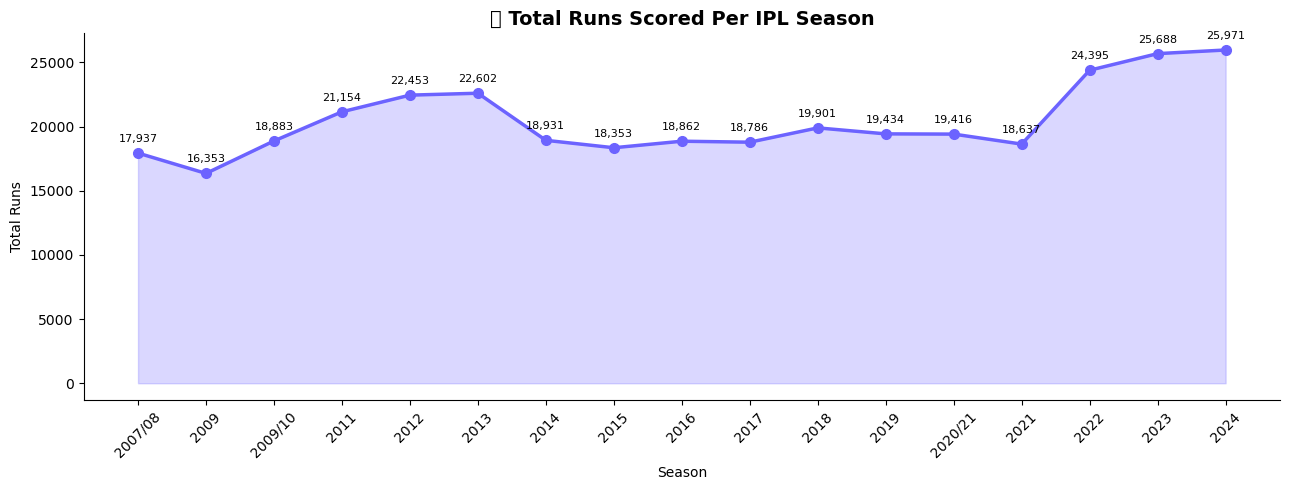

In [36]:
matches_season = matches_clean[['id', 'season']].rename(columns={'id': 'match_id'})
deliveries_merged = deliveries_clean.merge(matches_season, on='match_id')

season_runs = (
    deliveries_merged
    .groupby('season')['total_runs']
    .sum()
    .reset_index()
    .sort_values('season')
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(season_runs['season'], season_runs['total_runs'],
                alpha=0.25, color='#6C63FF')
ax.plot(season_runs['season'], season_runs['total_runs'],
        marker='o', color='#6C63FF', linewidth=2.5, markersize=7)

for _, row in season_runs.iterrows():
    ax.annotate(f"{int(row['total_runs']):,}",
                (row['season'], row['total_runs']),
                textcoords="offset points", xytext=(0, 8),
                ha='center', fontsize=8)

ax.set_xlabel('Season')
ax.set_ylabel('Total Runs')
ax.set_title('📈 Total Runs Scored Per IPL Season', fontsize=14, fontweight='bold')
ax.set_xticks(season_runs['season'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('insight5_season_runs.png', dpi=150, bbox_inches='tight')
plt.show()

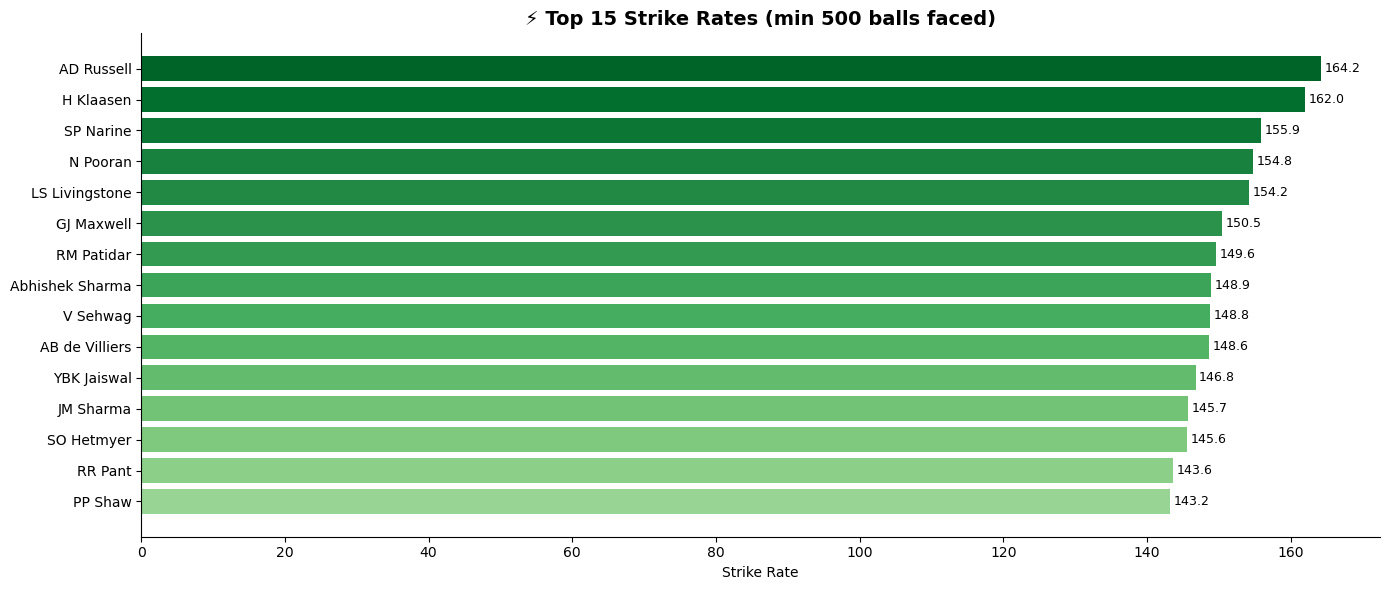

In [37]:
strike_rate = (
    deliveries_clean
    .groupby('batter')
    .agg(runs=('batsman_runs', 'sum'), balls=('ball', 'count'))
    .query('balls >= 500')
    .assign(strike_rate=lambda x: (x['runs'] / x['balls']) * 100)
    .sort_values('strike_rate', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.Greens(np.linspace(0.4, 0.9, 15))[::-1]
bars = ax.barh(strike_rate['batter'], strike_rate['strike_rate'], color=colors)

for bar, val in zip(bars, strike_rate['strike_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

ax.set_xlabel('Strike Rate')
ax.set_title('⚡ Top 15 Strike Rates (min 500 balls faced)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('insight6_strike_rate.png', dpi=150, bbox_inches='tight')
plt.show()

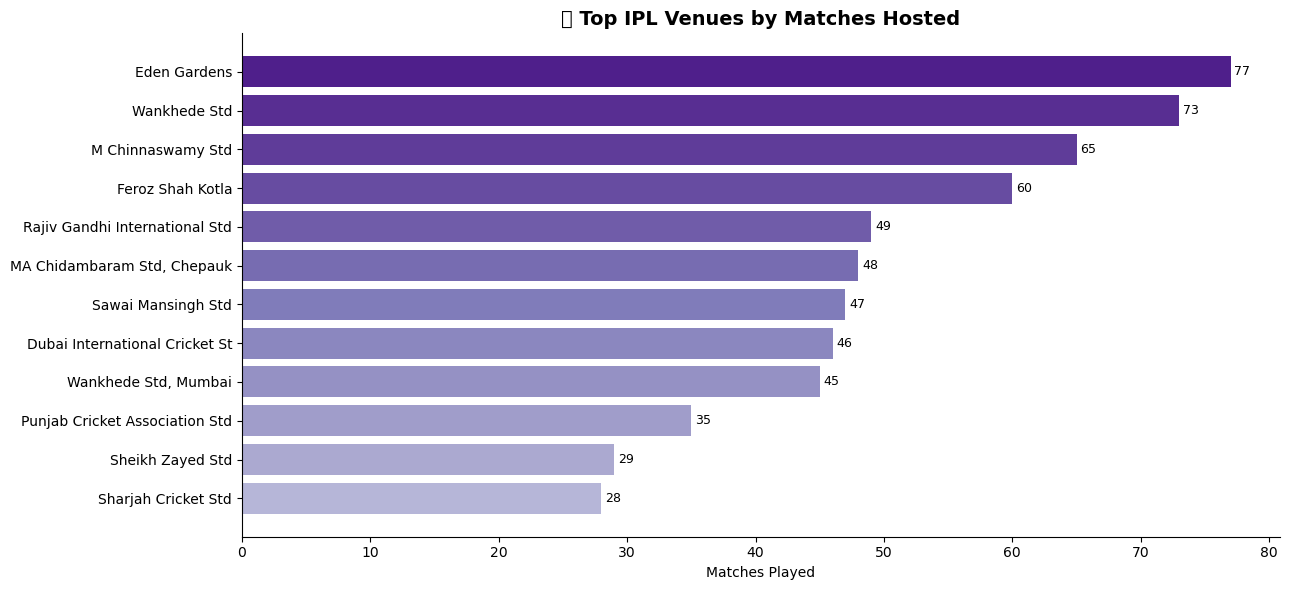

In [38]:
venue_counts = (
    matches_clean['venue']
    .value_counts()
    .head(12)
    .reset_index()
)
venue_counts.columns = ['Venue', 'Matches']

# Shorten long names
venue_counts['Venue'] = venue_counts['Venue'].str.replace('Stadium', 'Std').str[:30]

fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.Purples(np.linspace(0.4, 0.9, 12))[::-1]
bars = ax.barh(venue_counts['Venue'], venue_counts['Matches'], color=colors)

for bar, val in zip(bars, venue_counts['Matches']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Matches Played')
ax.set_title('🏟️ Top IPL Venues by Matches Hosted', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('insight7_venues.png', dpi=150, bbox_inches='tight')
plt.show()

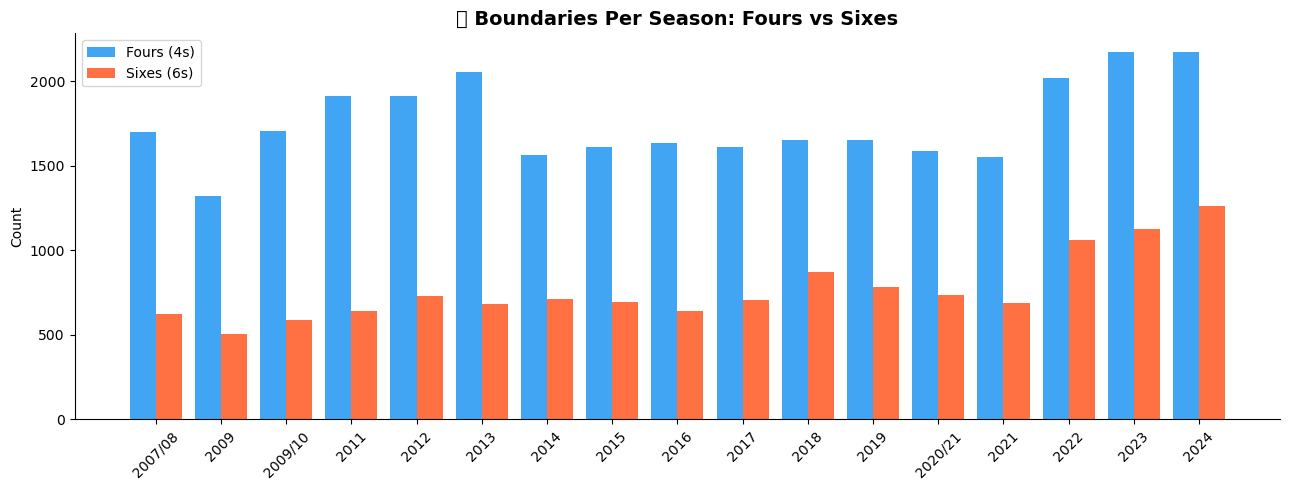


Total 4s in IPL history : 29,850
Total 6s in IPL history : 13,051


In [39]:
deliveries_merged['is_four'] = (deliveries_merged['batsman_runs'] == 4).astype(int)
deliveries_merged['is_six']  = (deliveries_merged['batsman_runs'] == 6).astype(int)

boundaries = (
    deliveries_merged
    .groupby('season')[['is_four', 'is_six']]
    .sum()
    .reset_index()
    .sort_values('season')
)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(boundaries))
w = 0.4
ax.bar(x - w/2, boundaries['is_four'], w, label='Fours (4s)', color='#2196F3', alpha=0.85)
ax.bar(x + w/2, boundaries['is_six'],  w, label='Sixes (6s)', color='#FF5722', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(boundaries['season'], rotation=45)
ax.set_ylabel('Count')
ax.set_title('💥 Boundaries Per Season: Fours vs Sixes', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('insight8_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal 4s in IPL history : {int(boundaries['is_four'].sum()):,}")
print(f"Total 6s in IPL history : {int(boundaries['is_six'].sum()):,}")

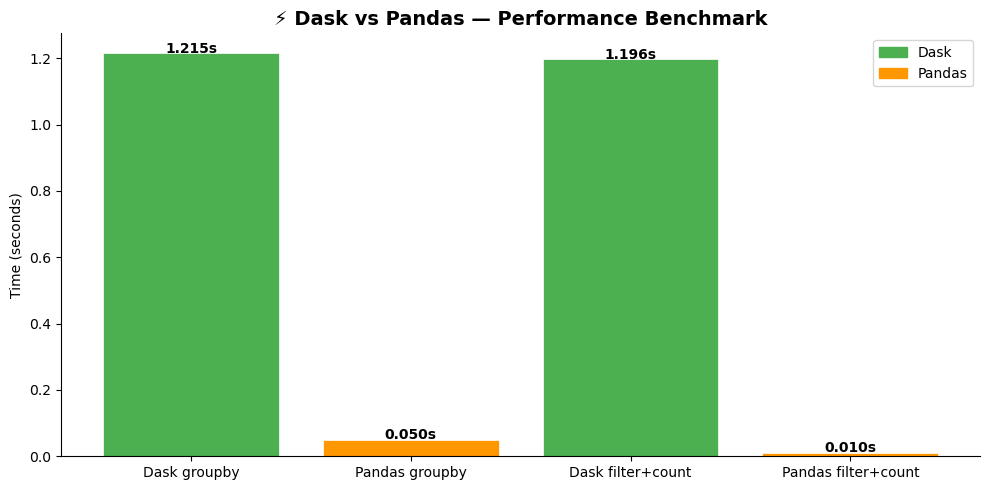


Note: Dask shows bigger advantage on larger datasets (100MB+)
On small datasets, Pandas overhead is lower due to no task graph setup.


In [40]:
import time

results = {}

# Test 1: GroupBy aggregation
t0 = time.time()
_ = deliveries_dask.groupby('batter')['batsman_runs'].sum().compute()
results['Dask groupby'] = time.time() - t0

t0 = time.time()
_ = deliveries_pd.groupby('batter')['batsman_runs'].sum()
results['Pandas groupby'] = time.time() - t0

# Test 2: Filter + count
t0 = time.time()
_ = deliveries_dask[deliveries_dask['batsman_runs'] == 6]['batter'].count().compute()
results['Dask filter+count'] = time.time() - t0

t0 = time.time()
_ = deliveries_pd[deliveries_pd['batsman_runs'] == 6]['batter'].count()
results['Pandas filter+count'] = time.time() - t0

# Plot benchmark
fig, ax = plt.subplots(figsize=(10, 5))
labels = list(results.keys())
times  = list(results.values())
colors = ['#4CAF50' if 'Dask' in l else '#FF9800' for l in labels]

bars = ax.bar(labels, times, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}s', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Time (seconds)')
ax.set_title('⚡ Dask vs Pandas — Performance Benchmark', fontsize=14, fontweight='bold')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#4CAF50', label='Dask'),
    plt.Rectangle((0,0),1,1, color='#FF9800', label='Pandas')
], loc='upper right')

plt.tight_layout()
plt.savefig('benchmark_dask_vs_pandas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: Dask shows bigger advantage on larger datasets (100MB+)")
print("On small datasets, Pandas overhead is lower due to no task graph setup.")

In [41]:
print("=" * 60)
print("        📊 IPL BIG DATA ANALYSIS — SUMMARY")
print("=" * 60)

top_scorer  = batsman_runs_dask.iloc[0]
top_bowler  = top_bowlers.iloc[0]
top_team    = team_wins.iloc[0]
toss_pct    = toss_effect[True] / toss_effect.sum() * 100

print(f"\n🏏  All-time top scorer  : {top_scorer['Batsman']} ({top_scorer['Total_Runs']:,} runs)")
print(f"🎯  All-time top bowler  : {top_bowler['Bowler']} ({top_bowler['Wickets']} wickets)")
print(f"🏆  Most successful team : {top_team['Team']} ({top_team['Wins']} wins)")
print(f"🎲  Toss → win rate      : {toss_pct:.1f}%  (small edge)")
print(f"\n📁  Dataset size         : {deliveries_pd.shape[0]:,} delivery records")
print(f"🔀  Dask partitions used  : {deliveries_dask.npartitions}")
print(f"\n✅  Tool used            : Dask (scalable, lazy evaluation)")
print(f"✅  Big data advantage   : Same code scales to 100GB+")
print(f"\n📌  Key finding: T20 cricket is increasingly dominated by")
print(f"    aggressive batting — sixes have grown each season,")
print(f"    while toss advantage is statistically marginal.")
print("=" * 60)

        📊 IPL BIG DATA ANALYSIS — SUMMARY

🏏  All-time top scorer  : V Kohli (8,014 runs)
🎯  All-time top bowler  : YS Chahal (205 wickets)
🏆  Most successful team : Mumbai Indians (144 wins)
🎲  Toss → win rate      : 50.6%  (small edge)

📁  Dataset size         : 260,920 delivery records
🔀  Dask partitions used  : 1

✅  Tool used            : Dask (scalable, lazy evaluation)
✅  Big data advantage   : Same code scales to 100GB+

📌  Key finding: T20 cricket is increasingly dominated by
    aggressive batting — sixes have grown each season,
    while toss advantage is statistically marginal.
